In [1]:
pip install nibabel matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import nibabel as nib
import matplotlib.animation as animation
import os
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Define the correct paths to images and labels
image_dir = '/content/drive/My Drive/Unet Dataset/imagesTr/'
mask_dir = '/content/drive/My Drive/Unet Dataset/labelsTr/'

In [5]:
# List files in the directories
image_files = os.listdir(image_dir)
mask_files = os.listdir(mask_dir)

print("Images:", image_files)
print("Masks:", mask_files)

Images: ['prostate_00.nii.gz', 'prostate_01.nii.gz', 'prostate_04.nii.gz', 'prostate_02.nii.gz', 'prostate_10.nii.gz', 'prostate_06.nii.gz', 'prostate_13.nii.gz', 'prostate_07.nii.gz', 'prostate_18.nii.gz', 'prostate_14.nii.gz', 'prostate_17.nii.gz', 'prostate_16.nii.gz', 'prostate_25.nii.gz', 'prostate_24.nii.gz', 'prostate_21.nii.gz', 'prostate_20.nii.gz', 'prostate_28.nii.gz', 'prostate_29.nii.gz', 'prostate_31.nii.gz', 'prostate_32.nii.gz', 'prostate_37.nii.gz', 'prostate_38.nii.gz', 'prostate_34.nii.gz', 'prostate_35.nii.gz', 'prostate_41.nii.gz', 'prostate_42.nii.gz', 'prostate_40.nii.gz', 'prostate_39.nii.gz', 'prostate_47.nii.gz', 'prostate_46.nii.gz', 'prostate_44.nii.gz', 'prostate_43.nii.gz']
Masks: ['prostate_02.nii.gz', 'prostate_01.nii.gz', 'prostate_00.nii.gz', 'prostate_20.nii.gz', 'prostate_10.nii.gz', 'prostate_06.nii.gz', 'prostate_07.nii.gz', 'prostate_13.nii.gz', 'prostate_14.nii.gz', 'prostate_16.nii.gz', 'prostate_04.nii.gz', 'prostate_17.nii.gz', 'prostate_18.ni

In [6]:
common_files = set(image_files).intersection(set(mask_files))

image_files = [f for f in image_files if f in common_files]
mask_files = [f for f in mask_files if f in common_files]

In [7]:
image_files = [f for f in image_files if not f.startswith('.')]
mask_files = [f for f in mask_files if not f.startswith('.')]

In [8]:
image_files.sort()
mask_files.sort()

print("Nmber of Images:", len(image_files))
print("Number of Masks:", len(mask_files))

print("Images:", image_files)
print("Masks:", mask_files)

Nmber of Images: 32
Number of Masks: 32
Images: ['prostate_00.nii.gz', 'prostate_01.nii.gz', 'prostate_02.nii.gz', 'prostate_04.nii.gz', 'prostate_06.nii.gz', 'prostate_07.nii.gz', 'prostate_10.nii.gz', 'prostate_13.nii.gz', 'prostate_14.nii.gz', 'prostate_16.nii.gz', 'prostate_17.nii.gz', 'prostate_18.nii.gz', 'prostate_20.nii.gz', 'prostate_21.nii.gz', 'prostate_24.nii.gz', 'prostate_25.nii.gz', 'prostate_28.nii.gz', 'prostate_29.nii.gz', 'prostate_31.nii.gz', 'prostate_32.nii.gz', 'prostate_34.nii.gz', 'prostate_35.nii.gz', 'prostate_37.nii.gz', 'prostate_38.nii.gz', 'prostate_39.nii.gz', 'prostate_40.nii.gz', 'prostate_41.nii.gz', 'prostate_42.nii.gz', 'prostate_43.nii.gz', 'prostate_44.nii.gz', 'prostate_46.nii.gz', 'prostate_47.nii.gz']
Masks: ['prostate_00.nii.gz', 'prostate_01.nii.gz', 'prostate_02.nii.gz', 'prostate_04.nii.gz', 'prostate_06.nii.gz', 'prostate_07.nii.gz', 'prostate_10.nii.gz', 'prostate_13.nii.gz', 'prostate_14.nii.gz', 'prostate_16.nii.gz', 'prostate_17.nii.gz

Image data shape: (320, 320, 15, 2)
Mask data shape: (320, 320, 15)


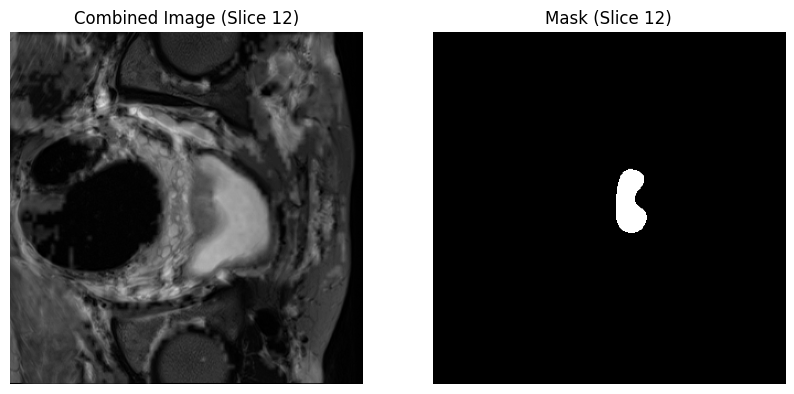

In [9]:
first_image = image_files[0]
first_mask = mask_files[0]

first_image_path = f'/content/drive/My Drive/Unet Dataset/imagesTr/{first_image}'
first_label_path = f'/content/drive/My Drive/Unet Dataset/labelsTr/{first_mask}'

image_nii = nib.load(first_image_path)
image_data = image_nii.get_fdata()

mask_nii = nib.load(first_label_path)
mask_data = mask_nii.get_fdata()

print("Image data shape:", image_data.shape)
print("Mask data shape:", mask_data.shape)

# Choose a specific slice to visualize
slice_idx = 12 # Example slice index
channel_0 = image_data[:, :, slice_idx, 0]
channel_1 = image_data[:, :, slice_idx, 1]

# Normalize channels for better visualization (0 to 1)
channel_0 = (channel_0 - np.min(channel_0)) / (np.max(channel_0) - np.min(channel_0))
channel_1 = (channel_1 - np.min(channel_1)) / (np.max(channel_1) - np.min(channel_1))

# Combine the channels (weighted sum)l
combined_image = (0.5 * channel_0 + 0.5 * channel_1)  # Adjust weights as necessary

# Extract the corresponding slice from the mask
mask_slice = mask_data[:, :, slice_idx]

# Plot both the combined image and the mask side by side
plt.figure(figsize=(10, 5))

# Plot the MRI image (combined)
plt.subplot(1, 2, 1)
plt.imshow(combined_image, cmap='gray', vmin=0, vmax=1)
plt.title(f"Combined Image (Slice {slice_idx})")
plt.axis('off')

# Plot the corresponding mask
plt.subplot(1, 2, 2)
plt.imshow(mask_slice, cmap='gray', vmin=0, vmax=1)  # Use 'gray' or any other colormap for the mask
plt.title(f"Mask (Slice {slice_idx})")
plt.axis('off')

plt.show()

Image data shape: (320, 320, 15, 2)
Mask data shape: (320, 320, 15)


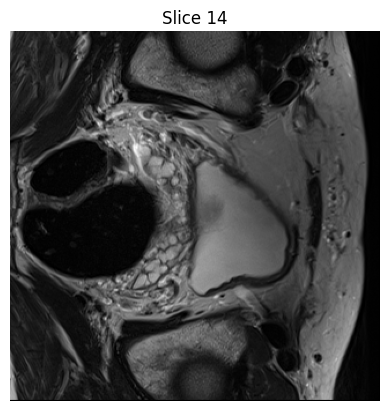

In [10]:
import matplotlib.animation as animation

# Load the first image
first_image = image_files[0]
first_image_path = f'/content/drive/My Drive/Unet Dataset/imagesTr/{first_image}'

image_nii = nib.load(first_image_path)
image_data = image_nii.get_fdata()

print("Image data shape:", image_data.shape)

first_mask = mask_files[0]
first_mask_path = f'/content/drive/My Drive/Unet Dataset/labelsTr/{first_mask}'
mask_nii = nib.load(first_mask_path)
mask_data = mask_nii.get_fdata()

print("Mask data shape:", mask_data.shape)  # Check the shape of the mask

# Ensure the mask shape matches the image shape
if mask_data.shape != image_data.shape[:3]:
    raise ValueError("Mask dimensions do not match image dimensions.")

# Create a figure for animation
fig, ax = plt.subplots()

# Function to update the frame
def update(frame):
    ax.clear()  # Clear the axis for new data

    # Get the grayscale image and the corresponding mask
    img_slice = image_data[:, :, frame, 0]  # First channel of the image
    mask_slice = mask_data[:, :, frame]      # Corresponding mask slice

    # Small value to avoid division by zero
    epsilon = 1e-8

    # Normalize the grayscale image
    img_slice_normalized = (img_slice - np.min(img_slice)) / (np.max(img_slice) - np.min(img_slice) + epsilon)

    # Create an RGB image for overlay
    rgba_image = np.zeros((*img_slice.shape, 3))  # RGB image

    # Assign grayscale values
    rgba_image[..., 0] = img_slice_normalized  # Red channel
    rgba_image[..., 1] = img_slice_normalized  # Green channel
    rgba_image[..., 2] = img_slice_normalized  # Blue channel

    # Overlay the mask in faint blue
    alpha = 0.5  # Adjust this value to change the faintness of the mask overlay (0 to 1)
    rgba_image[..., 0] = np.where(mask_slice > 0, rgba_image[..., 0] * (1 - alpha), rgba_image[..., 0])  # Adjust red channel
    rgba_image[..., 1] = np.where(mask_slice > 0, rgba_image[..., 1] * (1 - alpha), rgba_image[..., 1])  # Adjust green channel
    rgba_image[..., 2] = np.where(mask_slice > 0, (0.5 * alpha) + rgba_image[..., 2] * (1 - alpha), rgba_image[..., 2])

    # Display the combined image
    ax.imshow(rgba_image)
    ax.set_title(f"Slice {frame}")  # Set title for the current frame
    ax.axis('off')  # Hide axes

# Create an animation
ani = animation.FuncAnimation(fig, update, frames=image_data.shape[2], repeat=True)

# Save the animation as a GIF
ani.save('prostate_mri_animation.gif', writer='pillow', fps=10)

# Show the animation
plt.show()

In [11]:
from torch.utils.data import DataLoader, TensorDataset
from scipy.ndimage import zoom
import tensorflow as tf

# Data preparation
images = []
masks = []

target_depth = 20
target_size = (320, 320)

# Loop through all image and mask pairs
for i, (image_file, mask_file) in enumerate(zip(image_files, mask_files)):
    image_path = os.path.join(image_dir, image_file)
    mask_path = os.path.join(mask_dir, mask_file)

    image_nii = nib.load(image_path)
    mask_nii = nib.load(mask_path)

    image_data = image_nii.get_fdata()
    mask_data = mask_nii.get_fdata()

    # Normalize the grayscale image data to [0, 1]
    min_val = np.min(image_data)
    max_val = np.max(image_data)

    # Avoid division by zero
    if max_val - min_val > 0:
        image_data = (image_data - min_val) / (max_val - min_val)

    # Resize the image and mask to the target size (320x320)
    zoom_factors_image = (
        target_size[0] / image_data.shape[0],
        target_size[1] / image_data.shape[1],
        1,  # Depth should remain the same
        1  # Channels should remain the same
    )
    zoom_factors_mask = (
        target_size[0] / mask_data.shape[0],
        target_size[1] / mask_data.shape[1],
        1  # Depth should remain the same
    )

    image_data = zoom(image_data, zoom_factors_image, order=1)  # Linear interpolation for images
    mask_data = zoom(mask_data, zoom_factors_mask, order=0)  # Nearest-neighbor interpolation for masks

    # Adjust depth to match target depth
    current_depth = image_data.shape[2]

    if current_depth < target_depth:  # If depth is less than target, pad it
        padding_needed = target_depth - current_depth
        pad_width_image = ((0, 0), (0, 0), (0, padding_needed), (0, 0))  # Pad depth axis for image
        pad_width_mask = ((0, 0), (0, 0), (0, padding_needed))  # Pad depth axis for mask
        image_data = np.pad(image_data, pad_width_image, mode='constant', constant_values=0)
        mask_data = np.pad(mask_data, pad_width_mask, mode='constant', constant_values=0)
    elif current_depth > target_depth:  # If depth is greater than target, crop it
        image_data = image_data[:, :, :target_depth, :]  # Crop depth axis for image
        mask_data = mask_data[:, :, :target_depth]  # Crop depth axis for mask

    # Append to lists
    images.append(image_data)
    masks.append(mask_data)

images = np.array(images)
masks = np.array(masks)

images_tensors = torch.FloatTensor(images)
masks_tensors = torch.tensor(masks, dtype=torch.int64)

# One-hot encoded masks
# masks_onehot_tensors = torch.nn.functional.one_hot(masks_tensors, num_classes=3)

print(images_tensors.shape)
print(masks_tensors.shape)

torch.Size([32, 320, 320, 20, 2])
torch.Size([32, 320, 320, 20])


In [12]:
# Permute the data to fit in Conv3d
images_tensors = images_tensors.permute(0, 4, 3, 1, 2)
masks_tensors = masks_tensors.permute(0, 3, 1, 2)

print(f'Images shape: {images_tensors.shape}')
print(f'Masks shape: {masks_tensors.shape}')

Images shape: torch.Size([32, 2, 20, 320, 320])
Masks shape: torch.Size([32, 20, 320, 320])


In [13]:
# Print unique values, min, and max values of the images
unique_values = torch.unique(images_tensors)
min_value = torch.min(images_tensors)
max_value = torch.max(images_tensors)

print(f"Unique values in the first batch of images: {unique_values}")
print(f"Min value in the first batch of iamges: {min_value.item()}")
print(f"Max value in the first batch of images: {max_value.item()}")

# Print unique values, min, and max values of the masks
unique_values = torch.unique(masks_tensors)
min_value = torch.min(masks_tensors)
max_value = torch.max(masks_tensors)

print(f"Unique values in the first batch of masks: {unique_values}")
print(f"Min value in the first batch of masks: {min_value.item()}")
print(f"Max value in the first batch of masks: {max_value.item()}")

Unique values in the first batch of images: tensor([0.0000e+00, 7.0062e-30, 8.8227e-30,  ..., 9.9933e-01, 9.9965e-01,
        1.0000e+00])
Min value in the first batch of iamges: 0.0
Max value in the first batch of images: 1.0
Unique values in the first batch of masks: tensor([0, 1, 2])
Min value in the first batch of masks: 0
Max value in the first batch of masks: 2


In [14]:
num_samples = images_tensors.size(0)

# Create an array of indices
indices = np.arange(num_samples)

# Shuffle the indices
np.random.shuffle(indices)

# Split indices for train, validation, and test sets
train_size = int(0.8 * num_samples)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Create datasets for train, validation, and test
train_dataset = TensorDataset(images_tensors[train_indices], masks_tensors[train_indices])
test_dataset = TensorDataset(images_tensors[test_indices], masks_tensors[test_indices])

# Create DataLoaders for each dataset
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Print the number of samples in each split
print(f"Training samples: {len(train_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")

Training samples: 25
Test samples: 7


In [15]:
class UNet3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNet3D, self).__init__()

        # Encoder
        self.encoder1 = self.conv_block(in_channels, 64)
        self.encoder2 = self.conv_block(64, 128)
        self.encoder3 = self.conv_block(128, 256)
        self.encoder4 = self.conv_block(256, 512)

        # Bottleneck
        self.bottleneck = self.conv_block(512, 1024)

        # Decoder
        self.upconv4 = self.upconv(1024, 512)
        self.decoder4 = self.conv_block(1024, 512)

        self.upconv3 = self.upconv(512, 256)
        self.decoder3 = self.conv_block(512, 256)

        self.upconv2 = self.upconv(256, 128)
        self.decoder2 = self.conv_block(256, 128)

        self.upconv1 = self.upconv(128, 64)
        self.decoder1 = self.conv_block(128, 64)

        # Final output layer
        self.final_conv = nn.Conv3d(64, out_channels, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )

    def upconv(self, in_channels, out_channels):
        return nn.ConvTranspose3d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        # Encoder
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(F.max_pool3d(enc1, 2))
        enc3 = self.encoder3(F.max_pool3d(enc2, 2))
        enc4 = self.encoder4(F.max_pool3d(enc3, 2))

        # Bottleneck
        bottleneck = self.bottleneck(F.max_pool3d(enc4, 2))

        # Decoder
        up4 = self.upconv4(bottleneck)
        up4 = self.pad_if_needed(up4, enc4)
        dec4 = self.decoder4(torch.cat([up4, enc4], dim=1))

        up3 = self.upconv3(dec4)
        up3 = self.pad_if_needed(up3, enc3)
        dec3 = self.decoder3(torch.cat([up3, enc3], dim=1))

        up2 = self.upconv2(dec3)
        up2 = self.pad_if_needed(up2, enc2)
        dec2 = self.decoder2(torch.cat([up2, enc2], dim=1))

        up1 = self.upconv1(dec2)
        up1 = self.pad_if_needed(up1, enc1)
        dec1 = self.decoder1(torch.cat([up1, enc1], dim=1))

        # Final output
        out = self.final_conv(dec1)

        return out

    def pad_if_needed(self, upsampled, encoded):
        """
        Pads the upsampled tensor to match the shape of the encoded tensor.
        """
        diff_depth = encoded.size(2) - upsampled.size(2)
        diff_height = encoded.size(3) - upsampled.size(3)
        diff_width = encoded.size(4) - upsampled.size(4)

        # Padding: (left, right, top, bottom, front, back)
        upsampled = F.pad(upsampled,
                          [diff_width // 2, diff_width - diff_width // 2,
                           diff_height // 2, diff_height - diff_height // 2,
                           diff_depth // 2, diff_depth - diff_depth // 2])
        return upsampled

unet_model = UNet3D(in_channels=2, out_channels=3)

In [16]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth  # Smoothing factor to avoid division by zero

    def forward(self, outputs, targets):
        # Apply softmax to get probabilities for each class
        outputs = F.softmax(outputs, dim=1)  # Shape: [batch_size, num_classes, depth, height, width]

        # Convert the targets to one-hot encoding
        num_classes = outputs.shape[1]
        targets_one_hot = F.one_hot(targets, num_classes).permute(0, 4, 1, 2, 3)  # Shape: [batch_size, num_classes, depth, height, width]
        targets_one_hot = targets_one_hot.float()  # Convert to float for multiplication

        # Flatten the outputs and targets for Dice calculation
        outputs_flat = outputs.view(outputs.size(0), outputs.size(1), -1)  # [batch_size, num_classes, num_voxels]
        targets_flat = targets_one_hot.view(targets_one_hot.size(0), targets_one_hot.size(1), -1)

        # Calculate Dice score for each class
        intersection = (outputs_flat * targets_flat).sum(dim=2)
        dice_score = (2.0 * intersection + self.smooth) / (outputs_flat.sum(dim=2) + targets_flat.sum(dim=2) + self.smooth)

        # Dice loss is 1 minus the dice score, averaged over all classes
        dice_loss = 1 - dice_score.mean()

        return dice_loss

In [18]:
def dice_coefficient(pred, target, target_class=2, epsilon=1e-6):
  pred = (pred == target_class).float()  # Binary mask for predicted class
  target = (target == target_class).float()  # Binary mask for target class

  intersection = (pred * target).sum()  # Intersection
  dice = (2 * intersection + epsilon) / (pred.sum() + target.sum() + epsilon)  # Dice score
  return dice

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


**Method 1**

If i use cross entropy loss function, I ll count the frequency of every class in the images and i ll adjust the weights according to them.
Not so big differences between the two class dice scores, but generally less accuracy or just need a lot more epochs.

In [22]:
# Count the frequencies of every class so if i use cross entropy loss
# I will adjust the weights for each class according to their frequency
total_class_counts = torch.zeros(3)
total_voxels = 0

for images, masks in train_loader:
  flat_masks = masks.flatten()

  class_counts = torch.bincount(flat_masks, minlength=3)

  total_class_counts += class_counts

  total_voxels += flat_masks.numel()

class_frequencies = total_class_counts.float() / total_voxels

print(f"Class 0 (Background) frequency: {class_frequencies[0]:.6f}")
print(f"Class 1 (Organ) frequency: {class_frequencies[1]:.6f}")
print(f"Class 2 (Tumor) frequency: {class_frequencies[2]:.6f}")

class_weights = 1.0 / class_frequencies
class_weights /= class_weights.sum()
class_weights = class_weights * 10

print(class_weights)

Class 0 (Background) frequency: 0.973718
Class 1 (Organ) frequency: 0.005264
Class 2 (Tumor) frequency: 0.021017
tensor([0.0430, 7.9626, 1.9944])


**Method 2**

Conbined cross entropy loss function with dice loss. So i ll calculate the dice loss and set weight to each loss so the total loss will be the sum of the two losses multiplied by its weight. The weights' sum prefered to be equal to 1, so the total loss will not be more bigger than the values of the bigger loss.

In [23]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth  # Smoothing factor to avoid division by zero

    def forward(self, outputs, targets):
        # Apply softmax to get probabilities for each class
        outputs = F.softmax(outputs, dim=1)  # Shape: [batch_size, num_classes, depth, height, width]

        # Convert the targets to one-hot encoding
        num_classes = outputs.shape[1]
        targets_one_hot = F.one_hot(targets, num_classes).permute(0, 4, 1, 2, 3)  # Shape: [batch_size, num_classes, depth, height, width]
        targets_one_hot = targets_one_hot.float()

        # Flatten the outputs and targets for Dice calculation
        outputs_flat = outputs.view(outputs.size(0), outputs.size(1), -1)  # [batch_size, num_classes, num_voxels]
        targets_flat = targets_one_hot.view(targets_one_hot.size(0), targets_one_hot.size(1), -1)

        # Calculate Dice score for each class
        intersection = (outputs_flat * targets_flat).sum(dim=2)
        dice_score = (2.0 * intersection + self.smooth) / (outputs_flat.sum(dim=2) + targets_flat.sum(dim=2) + self.smooth)

        # Dice loss is 1 minus the dice score, averaged over all classes
        dice_loss = 1 - dice_score.mean()

        return dice_loss

# Combined Dice and Cross-Entropy Loss
class CombinedLoss(nn.Module):
    def __init__(self, dice_weight=0.5, ce_weight=0.5):
        super(CombinedLoss, self).__init__()
        self.dice_loss = DiceLoss()
        self.ce_loss = nn.CrossEntropyLoss()
        self.dice_weight = dice_weight
        self.ce_weight = ce_weight

    def forward(self, outputs, targets):
        dice_loss = self.dice_loss(outputs, targets)
        ce_loss = self.ce_loss(outputs, targets)
        combined_loss = self.dice_weight * dice_loss + self.ce_weight * ce_loss
        return combined_loss

**Method 3**

Now i ll combine method 1 and method 2

In [24]:
ce_loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

class WeightedCombinedLoss(nn.Module):
    def __init__(self, num_classes, dice_weight=0.5, ce_weight=0.5, class_weights=None, smooth=1e-6):
        super(CombinedLoss, self).__init__()
        self.num_classes = num_classes
        self.dice_weight = dice_weight
        self.ce_weight = ce_weight
        self.smooth = smooth  # Small constant to avoid division by zero

        # Cross-Entropy Loss with class weights
        self.ce_loss_fn = nn.CrossEntropyLoss(weight=class_weights)

    def forward(self, outputs, targets):
        # Apply softmax to outputs to get probabilities for each class
        outputs_softmax = F.softmax(outputs, dim=1)  # Shape: [batch_size, num_classes, depth, height, width]

        # Compute Cross-Entropy Loss (pixel-wise)
        ce_loss = self.ce_loss_fn(outputs, targets)

        # Convert ground truth to one-hot encoding for Dice Loss
        targets_one_hot = F.one_hot(targets, self.num_classes).permute(0, 4, 1, 2, 3)  # Shape: [batch_size, num_classes, depth, height, width]
        targets_one_hot = targets_one_hot.float()

        # Dice Loss for all classes
        dice_loss_total = 0.0
        for class_idx in range(self.num_classes):
            # Flatten the predictions and ground truth for the specific class
            outputs_flat = outputs_softmax[:, class_idx].view(outputs.size(0), -1)
            targets_flat = targets_one_hot[:, class_idx].view(targets_one_hot.size(0), -1)

            # Compute Dice coefficient
            intersection = (outputs_flat * targets_flat).sum(dim=1)
            dice_score = (2.0 * intersection + self.smooth) / (outputs_flat.sum(dim=1) + targets_flat.sum(dim=1) + self.smooth)

            # Dice loss for this class
            dice_loss_class = 1 - dice_score.mean()
            dice_loss_total += dice_loss_class

        # Average Dice Loss across all classes
        dice_loss = dice_loss_total / self.num_classes

        # Combine Dice Loss and Cross-Entropy Loss
        combined_loss = self.dice_weight * dice_loss + self.ce_weight * ce_loss
        return combined_loss

**Method 4**

In the Dynamic Weighted Dice Loss, I combine Cross-Entropy Loss and Dice Loss. I use multipliers for each class (equal to the number of classes). The class with the highest Dice loss (worst performance) is multiplied by the largest multiplier, while the best-performing class gets the smallest. This ensures that, even if one class is predicted well and another poorly, the penalization reflects the underperforming class more, encouraging the model to focus on improving it.

In [25]:
class DynamicWeightedDiceLoss(nn.Module):
    def __init__(self, num_classes, ce_weight=0.5, dice_weight=0.5, smooth=1e-6):
        super(DynamicWeightedDiceLoss, self).__init__()
        self.num_classes = num_classes
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth

        # Set multipliers (m1, m2, m3) for the sorted Dice losses
        self.multipliers = [1, 1.5, 2]  # You can change these values if needed

        # Cross-Entropy Loss
        self.ce_loss_fn = nn.CrossEntropyLoss()

    def forward(self, outputs, targets):
        # Apply softmax to outputs to get probabilities for each class
        outputs_softmax = F.softmax(outputs, dim=1)  # Shape: [batch_size, num_classes, depth, height, width]

        # Compute Cross-Entropy Loss (pixel-wise)
        ce_loss = self.ce_loss_fn(outputs, targets)

        # Convert ground truth to one-hot encoding for Dice Loss
        targets_one_hot = F.one_hot(targets, self.num_classes).permute(0, 4, 1, 2, 3)  # Shape: [batch_size, num_classes, depth, height, width]
        targets_one_hot = targets_one_hot.float()

        # Store Dice losses for each class
        dice_losses = []

        # Calculate Dice Loss for each class
        for class_idx in range(self.num_classes):
            # Flatten the predictions and ground truth for the specific class
            outputs_flat = outputs_softmax[:, class_idx].view(outputs.size(0), -1)
            targets_flat = targets_one_hot[:, class_idx].view(targets_one_hot.size(0), -1)

            # Compute Dice coefficient
            intersection = (outputs_flat * targets_flat).sum(dim=1)
            dice_score = (2.0 * intersection + self.smooth) / (outputs_flat.sum(dim=1) + targets_flat.sum(dim=1) + self.smooth)

            # Dice loss for this class
            dice_loss_class = 1 - dice_score.mean()
            dice_losses.append(dice_loss_class)

        # Sort the Dice losses and assign multipliers dynamically
        sorted_dice_losses = sorted(enumerate(dice_losses), key=lambda x: x[1], reverse=True)  # Sort by dice loss value
        sorted_indices = [idx for idx, _ in sorted_dice_losses]  # Get the sorted indices

        # Assign multipliers based on the ranking of Dice losses
        weighted_dice_loss = 0.0
        for rank, class_idx in enumerate(sorted_indices):
            weighted_dice_loss += self.multipliers[rank] * dice_losses[class_idx]

        # Normalize the weighted Dice loss by dividing by the number of classes
        weighted_dice_loss /= self.num_classes

        # Combine Dice Loss and Cross-Entropy Loss
        combined_loss = self.ce_weight * ce_loss + self.dice_weight * weighted_dice_loss
        return combined_loss

**Method 5**

Calculate tvesky loss which is:  true positives / ground truth + a * false positives + b * false negatives
(needs one-hot encoded ground truth also)

In [26]:
class TverskyLoss(nn.Module):
    def __init__(self, num_classes, alpha=0.5, beta=0.5, smooth=1e-6):
        super(TverskyLoss, self).__init__()
        self.num_classes = num_classes
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, outputs, targets):
        # Apply softmax to outputs to get probabilities for each class
        outputs_softmax = F.softmax(outputs, dim=1)  # Shape: [batch_size, num_classes, depth, height, width]

        # Convert the targets to one-hot encoding
        targets_one_hot = F.one_hot(targets, self.num_classes).permute(0, 4, 1, 2, 3)  # Shape: [batch_size, num_classes, depth, height, width]
        targets_one_hot = targets_one_hot.float()

        # Initialize Tversky loss for all classes
        tversky_loss_total = 0.0

        # Calculate Tversky Loss for each class
        for class_idx in range(self.num_classes):
            # Flatten the predictions and ground truth for the specific class
            outputs_flat = outputs_softmax[:, class_idx].view(outputs.size(0), -1)
            targets_flat = targets_one_hot[:, class_idx].view(targets_one_hot.size(0), -1)

            # Calculate true positives, false positives, and false negatives
            true_positives = (outputs_flat * targets_flat).sum(dim=1)
            false_positives = (outputs_flat * (1 - targets_flat)).sum(dim=1)
            false_negatives = ((1 - outputs_flat) * targets_flat).sum(dim=1)

            # Tversky Index for the class
            tversky_index = (true_positives + self.smooth) / (
                true_positives + self.alpha * false_positives + self.beta * false_negatives + self.smooth
            )

            # Tversky loss for the class
            tversky_loss_class = 1 - tversky_index.mean()

            # Accumulate Tversky loss for all classes
            tversky_loss_total += tversky_loss_class

        # Average Tversky loss over all classes
        tversky_loss = tversky_loss_total / self.num_classes

        return tversky_loss

In [36]:
import torch.optim as optim
from tqdm import tqdm

# Move model to device
unet_model = unet_model.to(device)

# Method 1
# criterion = nn.CrossEntropyLoss(weight=class_weights).to(device)

# Method 2
# criterion = CombinedLoss(dice_weight=0.5, ce_weight=0.5).to(device)

# Method 3
# criterion = WeightedCombinedLoss(num_classes=3, dice_weight=0.6, ce_weight=0.4, class_weights=class_weights).to(device)

# Method 4
# criterion = DynamicWeightedDiceLoss(num_classes=3, ce_weight=0.4, dice_weight=0.6).to(device)

# Method 5
criterion = TverskyLoss(num_classes=3, alpha=0.5, beta=0.5).to(device)

# Define the optimizer with L2 regularization (weight decay)
optimizer = optim.Adam(unet_model.parameters(), lr=0.001, weight_decay=1e-4)

# Training loop with Dice Coefficient tracking
num_epochs = 20
report_interval = 10  # Report every 10 batches

for epoch in range(num_epochs):
    # Training phase
    unet_model.train()
    running_loss = 0.0
    correct_pixels = 0
    total_pixels = 0

    dice_scores_class_1 = []
    dice_scores_class_2 = []

    # Create a tqdm progress bar
    with tqdm(total=len(train_loader), desc=f"Epoch {epoch + 1}/{num_epochs}", unit="batch") as pbar:
        for i, (images, masks) in enumerate(train_loader):
            # Move data to GPU
            images = images.to(device)
            masks = masks.to(device)

            # Forward pass
            logits = unet_model(images)

            # Calculate loss
            loss = criterion(logits, masks)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Track running loss
            running_loss += loss.item() * masks.size(0)  # Multiply by batch size to accumulate properly

            with torch.no_grad():
                predicted_classes = torch.argmax(logits, dim=1)  # Shape: [batch_size, depth, height, width]
                correct_pixels += (predicted_classes == masks).sum().item()  # Count correct predictions
                total_pixels += masks.numel()  # Total number of pixels

                # Calculate Dice coefficient for class 1 and class 2
                dice_score_class_1 = dice_coefficient(predicted_classes, masks, target_class=1)
                dice_score_class_2 = dice_coefficient(predicted_classes, masks, target_class=2)

                dice_scores_class_1.append(dice_score_class_1.item())
                dice_scores_class_2.append(dice_score_class_2.item())

            # Print average loss and accuracy at specified intervals
            if (i + 1) % report_interval == 0:
                epoch_loss = running_loss / ((i + 1) * masks.size(0))  # Calculate average loss up to current batch
                epoch_accuracy = correct_pixels / total_pixels  # Calculate accuracy up to current batch
                average_dice_class_1 = sum(dice_scores_class_1) / len(dice_scores_class_1)  # Average Dice score for class 1
                average_dice_class_2 = sum(dice_scores_class_2) / len(dice_scores_class_2)  # Average Dice score for class 2

                # Update tqdm description
                pbar.set_postfix(loss=epoch_loss, accuracy=epoch_accuracy,
                                 dice_class_1=average_dice_class_1,
                                 dice_class_2=average_dice_class_2)
                pbar.update(report_interval)

            pbar.update(1)  # Update tqdm progress bar

    # Calculate average loss and accuracy for the epoch
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = correct_pixels / total_pixels
    average_dice_class_1 = sum(dice_scores_class_1) / len(dice_scores_class_1) if dice_scores_class_1 else 0.0
    average_dice_class_2 = sum(dice_scores_class_2) / len(dice_scores_class_2) if dice_scores_class_2 else 0.0

    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.4f}, "
          f"Accuracy: {epoch_accuracy:.4f}, "
          f"Dice Score (class 1): {average_dice_class_1:.4f}, "
          f"Dice Score (class 2): {average_dice_class_2:.4f}")
    print('')

Epoch 1/20: 45batch [01:31,  2.03s/batch, accuracy=0.985, dice_class_1=0.546, dice_class_2=0.719, loss=0.256]


Epoch [1/20], Loss: 0.2559, Accuracy: 0.9861, Dice Score (class 1): 0.5547, Dice Score (class 2): 0.7126



Epoch 2/20: 45batch [01:31,  2.03s/batch, accuracy=0.989, dice_class_1=0.564, dice_class_2=0.737, loss=0.243]


Epoch [2/20], Loss: 0.2474, Accuracy: 0.9868, Dice Score (class 1): 0.5564, Dice Score (class 2): 0.7302



Epoch 3/20: 45batch [01:31,  2.03s/batch, accuracy=0.987, dice_class_1=0.571, dice_class_2=0.74, loss=0.24]


...

Epoch [18/20], Loss: 0.1911, Accuracy: 0.9897, Dice Score (class 1): 0.6523, Dice Score (class 2): 0.7884



Epoch 19/20: 45batch [01:31,  2.03s/batch, accuracy=0.989, dice_class_1=0.651, dice_class_2=0.781, loss=0.194]


Epoch [19/20], Loss: 0.1906, Accuracy: 0.9894, Dice Score (class 1): 0.6523, Dice Score (class 2): 0.7908



Epoch 20/20: 45batch [01:31,  2.03s/batch, accuracy=0.99, dice_class_1=0.664, dice_class_2=0.805, loss=0.181]

Epoch [20/20], Loss: 0.1869, Accuracy: 0.9909, Dice Score (class 1): 0.6532, Dice Score (class 2): 0.7989



In [37]:
unet_model.eval()  # Set the model to evaluation mode
running_loss = 0.0
correct_pixels = 0
total_pixels = 0

dice_scores_class_1 = []
dice_scores_class_2 = []

with torch.no_grad():
  for images, masks in test_loader:
    # Move data to GPU
    images = images.to(device)
    masks = masks.to(device)

    # Forward pass
    logits = unet_model(images)

    # Calculate loss
    loss = criterion(logits, masks)
    running_loss += loss.item() * masks.size(0)

    predicted_classes = torch.argmax(logits, dim=1)
    correct_pixels += (predicted_classes == masks).sum().item()
    total_pixels += masks.numel()

    # Calculate Dice coefficient for class 1 and class 2
    dice_score_class_1 = dice_coefficient(predicted_classes, masks, target_class=1)
    dice_score_class_2 = dice_coefficient(predicted_classes, masks, target_class=2)

    dice_scores_class_1.append(dice_score_class_1.item())
    dice_scores_class_2.append(dice_score_class_2.item())

# Calculate average loss and accuracy for the test set
test_loss = running_loss / len(test_loader.dataset)
test_accuracy = correct_pixels / total_pixels
average_dice_class_1 = sum(dice_scores_class_1) / len(dice_scores_class_1) if dice_scores_class_1 else 0.0
average_dice_class_2 = sum(dice_scores_class_2) / len(dice_scores_class_2) if dice_scores_class_2 else 0.0

print(f"Test Loss: {test_loss:.4f}, "
      f"Test Accuracy: {test_accuracy:.4f}, "
      f"Test Dice Score (class 1): {average_dice_class_1:.4f}, "
      f"Test Dice Score (class 2): {average_dice_class_2:.4f}")

Test Loss: 0.3892, Test Accuracy: 0.9833, Test Dice Score (class 1): 0.3422, Test Dice Score (class 2): 0.4986


In [38]:
# Set the model to evaluation mode
unet_model.eval()

# Initialize variables for the single input, output, and mask
single_input = None
single_output = None
single_mask = None

# Disable gradient calculation for testing
with torch.no_grad():
    # Iterate over the test_loader
    for idx, (images, masks) in enumerate(test_loader):
        images = images.to(device)  # Move images to device
        masks = masks.to(device)    # Move masks to device

        # Forward pass to get model outputs
        outputs = unet_model(images)  # Get raw logits from the model

        # Apply argmax to get predicted classes from the logits
        predicted_classes = torch.argmax(outputs, dim=1)  # Shape: [B, D, H, W]

        # Store only the first input, output, and mask from the first batch
        if idx == 0:  # Check if we haven't already saved an input
            single_input = images[0].cpu()   # Save the first image's input and move it to CPU
            single_output = predicted_classes[0].cpu()  # Save the first image's predicted output
            single_mask = masks[0].cpu()       # Save the first image's mask and move it to CPU
            break  # Exit after processing the first batch


# You can now access single_output and single_mask
print(f'Single input image: {single_input.shape}')
print(f'Single output shape: {single_output.shape}')  # Check the shape of the output
print(f'Single mask shape: {single_mask.shape}')      # Check the shape of the mask

Single input image: torch.Size([2, 20, 320, 320])
Single output shape: torch.Size([20, 320, 320])
Single mask shape: torch.Size([20, 320, 320])


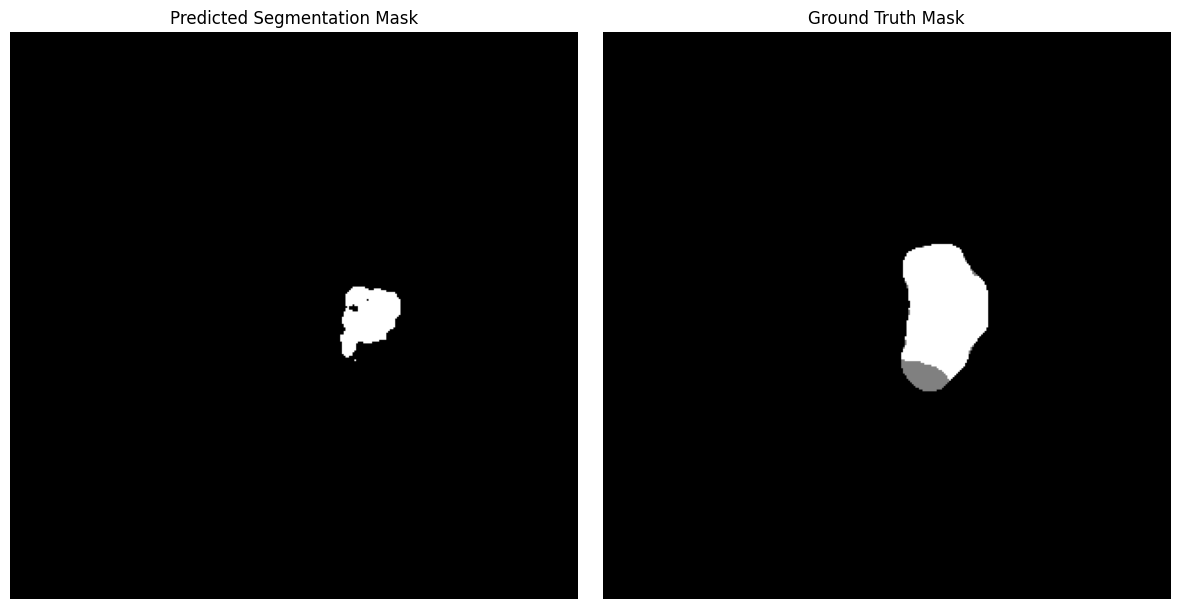

In [41]:
# Convert tensors to NumPy arrays
single_output_np = single_output.numpy()  # Shape: [20, 320, 320]
single_mask_np = single_mask.numpy()      # Shape: [20, 320, 320]

slice_index = 13

if 0 <= slice_index < single_output_np.shape[0]:  # Check against the first dimension
    # Extract the relevant slices
    single_output_slice = single_output_np[slice_index]  # Shape: (320, 320)
    single_mask_slice = single_mask_np[slice_index]      # Shape: (320, 320)

    # Now plot the results
    plt.figure(figsize=(12, 6))

    # Plotting the predicted output
    plt.subplot(1, 2, 1)
    plt.imshow(single_output_slice, cmap='gray', aspect='equal')  # Display the predicted output
    plt.title('Predicted Segmentation Mask')
    plt.axis('off')

    # Plotting the ground truth mask
    plt.subplot(1, 2, 2)
    plt.imshow(single_mask_slice, cmap='gray', aspect='equal')  # Display the ground truth mask
    plt.title('Ground Truth Mask')
    plt.axis('off')

    # Show the plots
    plt.tight_layout()  # Improve layout spacing
    plt.show()
else:
    print(f"Invalid slice index: {slice_index}")

In [42]:
single_input = single_input.permute(2, 3, 1, 0)
single_output = single_output.permute(1, 2, 0)
single_mask = single_mask.permute(1, 2, 0)

print(f'Single input image: {single_input.shape}')
print(f'Single output shape: {single_output.shape}')
print(f'Single mask shape: {single_mask.shape}')

Single input image: torch.Size([320, 320, 20, 2])
Single output shape: torch.Size([320, 320, 20])
Single mask shape: torch.Size([320, 320, 20])


In [43]:
# Convert input sample to NIfTI
input_volume = single_input.squeeze().cpu().numpy()  # Shape: [320, 320, 20]
nii_input_image = nib.Nifti1Image(input_volume, affine=np.eye(4))
nib.save(nii_input_image, 'input_sample.nii')

# Convert mask to NIfTI
mask_volume = single_mask.squeeze().cpu().numpy().astype(np.uint8)  # Shape: [320, 320, 20]
nii_mask_image = nib.Nifti1Image(mask_volume, affine=np.eye(4))
nib.save(nii_mask_image, 'ground_truth_mask.nii')

# Convert output to NIfTI (as done previously)
output_volume = single_output.squeeze().cpu().numpy().astype(np.uint8)  # Shape: [320, 320, 20]
nii_output_image = nib.Nifti1Image(output_volume, affine=np.eye(4))
nib.save(nii_output_image, 'predicted_output.nii')

print("NIfTI files saved: input_sample.nii, ground_truth_mask.nii, predicted_output.nii")

NIfTI files saved: input_sample.nii, ground_truth_mask.nii, predicted_output.nii


Input data shape: (320, 320, 20, 2)
Mask data shape: (320, 320, 20)
Predicted data shape: (320, 320, 20)


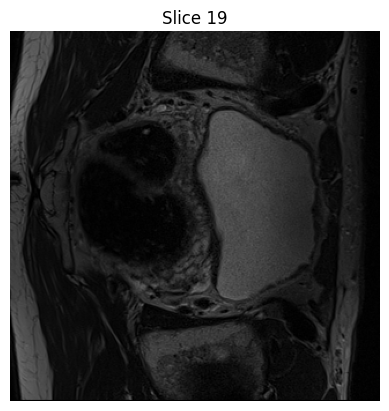

In [44]:
# Load the saved NIfTI files
input_nii = nib.load('input_sample.nii')
input_data = input_nii.get_fdata()

mask_nii = nib.load('ground_truth_mask.nii')
mask_data = mask_nii.get_fdata()

predicted_nii = nib.load('predicted_output.nii')
predicted_data = predicted_nii.get_fdata()

print("Input data shape:", input_data.shape)         # Check the shape of the input
print("Mask data shape:", mask_data.shape)           # Check the shape of the mask
print("Predicted data shape:", predicted_data.shape)  # Check the shape of the predicted output

# Create a figure for animation
fig, ax = plt.subplots()

# Function to update the frame for animation
def update(frame):
    ax.clear()  # Clear the axis for new data

    # Extract channels from input data
    channel_0 = input_data[:, :, frame, 0]  # First channel
    channel_1 = input_data[:, :, frame, 1]  # Second channel

    # Small value to avoid division by zero
    epsilon = 1e-8

    # Normalize channels for better visualization (0 to 1)
    channel_0 = (channel_0 - np.min(channel_0)) / (np.max(channel_0) - np.min(channel_0) + epsilon)
    channel_1 = (channel_1 - np.min(channel_1)) / (np.max(channel_1) - np.min(channel_1) + epsilon)

    # Combine the channels (weighted sum)
    combined_image = (0.5 * channel_0 + 0.5 * channel_1)  # Adjust weights as necessary

    # Extract the corresponding slice from the mask
    mask_slice = mask_data[:, :, frame]  # Shape: (320, 320)

    # Extract the corresponding slice from the predicted output
    pred_slice = predicted_data[:, :, frame]  # Shape: (320, 320)

    # Create an RGB image for overlay
    rgba_image = np.zeros((*combined_image.shape, 3))  # RGB image

    # Assign the normalized combined image to the red and green channels
    rgba_image[..., 0] = combined_image  # Red channel
    rgba_image[..., 1] = combined_image  # Green channel
    rgba_image[..., 2] = combined_image  # Blue channel

    # Overlay the predicted output in red
    pred_alpha = 0.5  # Adjust this value to change the faintness of the prediction overlay
    rgba_image[..., 0] = np.where(pred_slice > 0, (1 - pred_alpha) + rgba_image[..., 0] * pred_alpha, rgba_image[..., 0])  # Adjust red channel

    # Overlay the mask in blue
    mask_alpha = 1.9  # Adjust the transparency of the mask
    rgba_image[..., 2] = np.where(mask_slice > 0, (0.5 * mask_alpha) + rgba_image[..., 2] * (1 - mask_alpha), rgba_image[..., 2])  # Adjust blue channel

    # Display the combined image
    ax.imshow(rgba_image)
    ax.set_title(f"Slice {frame}")  # Set title for the current frame
    ax.axis('off')  # Hide axes

# Create an animation
ani = animation.FuncAnimation(fig, update, frames=input_data.shape[2], repeat=True)

# Save the animation as a GIF
ani.save('prostate_mri_animation_with_predictions.gif', writer='pillow', fps=10)

# Show the animation
plt.show()

DATA AUGMENTATION

In [1]:
import random
from torch.utils.data import Dataset

class Augmented3DDataset(Dataset):
    def __init__(self, volumes, masks, apply_cropping=True, apply_flipping=True):
        self.volumes = volumes
        self.masks = masks
        self.apply_cropping = apply_cropping
        self.apply_flipping = apply_flipping

    def __len__(self):
        return len(self.volumes)

    def center_crop_2d(self, volume, mask, target_height, target_width):
        _, _, depth, height, width = volume.shape

        # Calculate start and end indices for height
        start_height = (height - target_height) // 2
        end_height = start_height + target_height

        # Calculate start and end indices for width
        start_width = (width - target_width) // 2
        end_width = start_width + target_width

        # Crop volume and mask
        cropped_volume = volume[:, :, :, start_height:end_height, start_width:end_width]
        cropped_mask = mask[:, :, :, start_height:end_height, start_width:end_width]
        return cropped_volume, cropped_mask

    def random_flip(self, volume, mask):
        if random.random() > 0.5:
            # Apply horizontal flip
            flipped_volume = torch.flip(volume, dims=[4])
            flipped_mask = torch.flip(mask, dims=[4])
        else:
            # Apply vertical flip
            flipped_volume = torch.flip(volume, dims=[3])
            flipped_mask = torch.flip(mask, dims=[3])
        return flipped_volume, flipped_mask

    def __getitem__(self, idx):
        volume = self.volumes[idx].unsqueeze(0)  # Add channel dimension if needed
        mask = self.masks[idx].unsqueeze(0)  # Add channel dimension if needed

        # Apply center cropping if enabled
        if self.apply_cropping:
            volume, mask = self.center_crop_2d(volume, mask, target_height=256, target_width=256)

        # Apply random flipping if enabled
        if self.apply_flipping:
            volume, mask = self.random_flip(volume, mask)

        return volume, mask

In [2]:
existing_dataset = train_loader.dataset

image_tensors, mask_tensors = existing_dataset.tensors

aug_train_dataset = Augmented3DDataset(volumes=images_tensors, labels=masks_tensors)

aug_train_loader = DataLoader(aug_train_dataset, batch_size=4, shuffle=True, num_workers=4)

# Print the number of samples in each split
print(f"Training samples: {len(aug_train_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")

NameError: name 'train_loader' is not defined

In [ ]:
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

def augment_data(train_loader):
    augmented_images = []
    augmented_masks = []

    for images, masks in train_loader:
        for i in range(images.size(0)):  # Loop through each image in the batch
            # Original image and mask
            augmented_images.append(images[i])        # Original image
            augmented_masks.append(masks[i])          # Original mask

            # Horizontal Flip
            augmented_images.append(TF.hflip(images[i]))
            augmented_masks.append(TF.hflip(masks[i]))

            # Vertical Flip
            augmented_images.append(TF.vflip(images[i]))
            augmented_masks.append(TF.vflip(masks[i]))

    # Convert back to tensors
    augmented_images = torch.stack(augmented_images)
    augmented_masks = torch.stack(augmented_masks)

    # Create a new DataLoader for the augmented data
    augmented_dataset = TensorDataset(augmented_images, augmented_masks)
    augmented_loader = DataLoader(augmented_dataset, batch_size=3, shuffle=True)

    return augmented_loader

aug_train_loader = augment_data(train_loader)

# Print the number of samples in each split
print(f"Training samples: {len(aug_train_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")

In [ ]:
from tqdm import tqdm

import torch.optim as optim
from tqdm import tqdm

# Move model to device
unet_model = unet_model.to(device)

# Initialize the CrossEntropyLoss criterion
criterion = nn.CrossEntropyLoss()

# Define the optimizer with L2 regularization (weight decay)
optimizer = optim.Adam(unet_model.parameters(), lr=0.0001, weight_decay=1e-5)

# Training loop with Dice Coefficient tracking
num_epochs = 10
report_interval = 10  # Report every 10 batches

for epoch in range(num_epochs):
    # Training phase
    unet_model.train()
    running_loss = 0.0
    correct_pixels = 0
    total_pixels = 0

    dice_scores_class_1 = []
    dice_scores_class_2 = []

    # Create a tqdm progress bar
    with tqdm(total=len(aug_train_loader), desc=f"Epoch {epoch + 1}/{num_epochs}", unit="batch") as pbar:
        for i, (images, masks) in enumerate(aug_train_loader):
            # Move data to GPU
            images = images.to(device)
            masks = masks.to(device)

            # Forward pass
            logits = unet_model(images)

            # Calculate loss
            loss = criterion(logits, masks)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Track running loss
            running_loss += loss.item() * masks.size(0)  # Multiply by batch size to accumulate properly

            with torch.no_grad():
                predicted_classes = torch.argmax(logits, dim=1)  # Shape: [batch_size, depth, height, width]
                correct_pixels += (predicted_classes == masks).sum().item()  # Count correct predictions
                total_pixels += masks.numel()  # Total number of pixels

                # Calculate Dice coefficient for class 1 and class 2
                dice_score_class_1 = dice_coefficient(predicted_classes, masks, target_class=1)
                dice_score_class_2 = dice_coefficient(predicted_classes, masks, target_class=2)

                dice_scores_class_1.append(dice_score_class_1.item())
                dice_scores_class_2.append(dice_score_class_2.item())

            # Print average loss and accuracy at specified intervals
            if (i + 1) % report_interval == 0:
                epoch_loss = running_loss / ((i + 1) * masks.size(0))  # Calculate average loss up to current batch
                epoch_accuracy = correct_pixels / total_pixels  # Calculate accuracy up to current batch
                average_dice_class_1 = sum(dice_scores_class_1) / len(dice_scores_class_1)  # Average Dice score for class 1
                average_dice_class_2 = sum(dice_scores_class_2) / len(dice_scores_class_2)  # Average Dice score for class 2

                # Update tqdm description
                pbar.set_postfix(loss=epoch_loss, accuracy=epoch_accuracy,
                                 dice_class_1=average_dice_class_1,
                                 dice_class_2=average_dice_class_2)
                pbar.update(report_interval)

            # Update the tqdm progress bar for each batch processed
            pbar.update(1)

    # Calculate average loss and accuracy for the epoch
    epoch_loss = running_loss / len(aug_train_loader.dataset)
    epoch_accuracy = correct_pixels / total_pixels
    average_dice_class_1 = sum(dice_scores_class_1) / len(dice_scores_class_1) if dice_scores_class_1 else 0.0
    average_dice_class_2 = sum(dice_scores_class_2) / len(dice_scores_class_2) if dice_scores_class_2 else 0.0

    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.4f}, "
          f"Accuracy: {epoch_accuracy:.4f}, "
          f"Dice Score (class 1): {average_dice_class_1:.4f}, "
          f"Dice Score (class 2): {average_dice_class_2:.4f}")

In [ ]:
unet_model.eval()  # Set the model to evaluation mode
running_loss = 0.0
correct_pixels = 0
total_pixels = 0

dice_scores_class_1 = []
dice_scores_class_2 = []

with torch.no_grad():
  for images, masks in test_loader:
    # Move data to GPU
    images = images.to(device)
    masks = masks.to(device)

    # Forward pass
    logits = unet_model(images)

    # Calculate loss
    loss = criterion(logits, masks)
    running_loss += loss.item() * masks.size(0)

    predicted_classes = torch.argmax(logits, dim=1)
    correct_pixels += (predicted_classes == masks).sum().item()
    total_pixels += masks.numel()

    # Calculate Dice coefficient for class 1 and class 2
    dice_score_class_1 = dice_coefficient(predicted_classes, masks, target_class=1)
    dice_score_class_2 = dice_coefficient(predicted_classes, masks, target_class=2)

    dice_scores_class_1.append(dice_score_class_1.item())
    dice_scores_class_2.append(dice_score_class_2.item())

# Calculate average loss and accuracy for the test set
test_loss = running_loss / len(test_loader.dataset)
test_accuracy = correct_pixels / total_pixels
average_dice_class_1 = sum(dice_scores_class_1) / len(dice_scores_class_1) if dice_scores_class_1 else 0.0
average_dice_class_2 = sum(dice_scores_class_2) / len(dice_scores_class_2) if dice_scores_class_2 else 0.0

print(f"Test Loss: {test_loss:.4f}, "
      f"Test Accuracy: {test_accuracy:.4f}, "
      f"Test Dice Score (class 1): {average_dice_class_1:.4f}, "
      f"Test Dice Score (class 2): {average_dice_class_2:.4f}")

In [ ]:
# Set the model to evaluation mode
unet_model.eval()

# Initialize variables for the single input, output, and mask
single_input = None
single_output = None
single_mask = None

# Disable gradient calculation for testing
with torch.no_grad():
    # Iterate over the test_loader
    for idx, (images, masks) in enumerate(test_loader):
        images = images.to(device)  # Move images to device
        masks = masks.to(device)    # Move masks to device

        # Forward pass to get model outputs
        outputs = unet_model(images)  # Get raw logits from the model

        # Apply argmax to get predicted classes from the logits
        predicted_classes = torch.argmax(outputs, dim=1)  # Shape: [B, D, H, W]

        # Store only the first input, output, and mask from the first batch
        if idx == 0:  # Check if we haven't already saved an input
            single_input = images[0].cpu()   # Save the first image's input and move it to CPU
            single_output = predicted_classes[0].cpu()  # Save the first image's predicted output
            single_mask = masks[0].cpu()       # Save the first image's mask and move it to CPU
            break  # Exit after processing the first batch


# You can now access single_output and single_mask
print(f'Single input image: {single_input.shape}')
print(f'Single output shape: {single_output.shape}')  # Check the shape of the output
print(f'Single mask shape: {single_mask.shape}')      # Check the shape of the mask

In [ ]:
# Convert tensors to NumPy arrays
single_output_np = single_output.numpy()  # Shape: [20, 320, 320]
single_mask_np = single_mask.numpy()      # Shape: [20, 320, 320]

slice_index = 10

if 0 <= slice_index < single_output_np.shape[0]:  # Check against the first dimension
    # Extract the relevant slices
    single_output_slice = single_output_np[slice_index]  # Shape: (320, 320)
    single_mask_slice = single_mask_np[slice_index]      # Shape: (320, 320)

    # Now plot the results
    plt.figure(figsize=(12, 6))

    # Plotting the predicted output
    plt.subplot(1, 2, 1)
    plt.imshow(single_output_slice, cmap='gray', aspect='equal')  # Display the predicted output
    plt.title('Predicted Segmentation Mask')
    plt.axis('off')

    # Plotting the ground truth mask
    plt.subplot(1, 2, 2)
    plt.imshow(single_mask_slice, cmap='gray', aspect='equal')  # Display the ground truth mask
    plt.title('Ground Truth Mask')
    plt.axis('off')

    # Show the plots
    plt.tight_layout()  # Improve layout spacing
    plt.show()
else:
    print(f"Invalid slice index: {slice_index}")

In [ ]:
single_input = single_input.permute(2, 3, 1, 0)
single_output = single_output.permute(1, 2, 0)
single_mask = single_mask.permute(1, 2, 0)

print(f'Single input image: {single_input.shape}')
print(f'Single output shape: {single_output.shape}')
print(f'Single mask shape: {single_mask.shape}')

In [ ]:
# Convert input sample to NIfTI
input_volume = single_input.squeeze().cpu().numpy()  # Shape: [320, 320, 20]
nii_input_image = nib.Nifti1Image(input_volume, affine=np.eye(4))
nib.save(nii_input_image, 'input_sample1.nii')

# Convert mask to NIfTI
mask_volume = single_mask.squeeze().cpu().numpy().astype(np.uint8)  # Shape: [320, 320, 20]
nii_mask_image = nib.Nifti1Image(mask_volume, affine=np.eye(4))
nib.save(nii_mask_image, 'ground_truth_mask1.nii')

# Convert output to NIfTI (as done previously)
output_volume = single_output.squeeze().cpu().numpy().astype(np.uint8)  # Shape: [320, 320, 20]
nii_output_image = nib.Nifti1Image(output_volume, affine=np.eye(4))
nib.save(nii_output_image, 'predicted_output1.nii')

print("NIfTI files saved: input_sample1.nii, ground_truth_mask1.nii, predicted_output1.nii")

In [ ]:
# Load the saved NIfTI files
input_nii = nib.load('input_sample1.nii')
input_data = input_nii.get_fdata()

mask_nii = nib.load('ground_truth_mask1.nii')
mask_data = mask_nii.get_fdata()

predicted_nii = nib.load('predicted_output1.nii')
predicted_data = predicted_nii.get_fdata()

print("Input data shape:", input_data.shape)         # Check the shape of the input
print("Mask data shape:", mask_data.shape)           # Check the shape of the mask
print("Predicted data shape:", predicted_data.shape)  # Check the shape of the predicted output

# Create a figure for animation
fig, ax = plt.subplots()

# Function to update the frame for animation
def update(frame):
    ax.clear()  # Clear the axis for new data

    # Extract channels from input data
    channel_0 = input_data[:, :, frame, 0]  # First channel
    channel_1 = input_data[:, :, frame, 1]  # Second channel

    # Small value to avoid division by zero
    epsilon = 1e-8

    # Normalize channels for better visualization (0 to 1)
    channel_0 = (channel_0 - np.min(channel_0)) / (np.max(channel_0) - np.min(channel_0) + epsilon)
    channel_1 = (channel_1 - np.min(channel_1)) / (np.max(channel_1) - np.min(channel_1) + epsilon)

    # Combine the channels (weighted sum)
    combined_image = (0.5 * channel_0 + 0.5 * channel_1)  # Adjust weights as necessary

    # Extract the corresponding slice from the mask
    mask_slice = mask_data[:, :, frame]  # Shape: (320, 320)

    # Extract the corresponding slice from the predicted output
    pred_slice = predicted_data[:, :, frame]  # Shape: (320, 320)

    # Create an RGB image for overlay
    rgba_image = np.zeros((*combined_image.shape, 3))  # RGB image

    # Assign the normalized combined image to the red and green channels
    rgba_image[..., 0] = combined_image  # Red channel
    rgba_image[..., 1] = combined_image  # Green channel
    rgba_image[..., 2] = combined_image  # Blue channel

    # Overlay the predicted output in red
    pred_alpha = 0.8  # Adjust this value to change the faintness of the prediction overlay
    rgba_image[..., 0] = np.where(pred_slice > 0, (1 - pred_alpha) + rgba_image[..., 0] * pred_alpha, rgba_image[..., 0])  # Adjust red channel

    # Overlay the mask in blue
    mask_alpha = 1.9  # Adjust the transparency of the mask
    rgba_image[..., 2] = np.where(mask_slice > 0, (0.5 * mask_alpha) + rgba_image[..., 2] * (1 - mask_alpha), rgba_image[..., 2])  # Adjust blue channel

    # Display the combined image
    ax.imshow(rgba_image)
    ax.set_title(f"Slice {frame}")  # Set title for the current frame
    ax.axis('off')  # Hide axes

# Create an animation
ani = animation.FuncAnimation(fig, update, frames=input_data.shape[2], repeat=True)

# Save the animation as a GIF
ani.save('prostate_mri_animation_with_predictions1.gif', writer='pillow', fps=10)

# Show the animation
plt.show()